## Catalogue-wide similarity evaluation

Measures the similarity component across every cell line with a recorded lineage, rather than on a single example: same-lineage recovery in the top five, per-lineage separation, and whether label granularity explains it. Seeded throughout.

Reads: DepMap expression, proteomics, cell line dimension, signatures, DepMap sample info. Writes: `dim_cell_line_parents.csv`, `lineage_separation.png`, `lineage_concordance.png`.

`lineage_separation.png` is Figure B.1 in the report.

In [1]:
import duckdb
import numpy as np
import pandas as pd

pdir = "../../data/parquet"

# one row per cell line, one column per gene
expr = duckdb.sql(f"""
    SELECT ACH_ID, ensembl_id, median(log2_tpm_plus1) AS v
    FROM read_parquet('{pdir}/fact_expression_depmap.parquet')
    GROUP BY ACH_ID, ensembl_id
""").df()

print("long form:", expr.shape)

wide = expr.pivot(index="ACH_ID", columns="ensembl_id", values="v")
print("wide:", wide.shape)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

long form: (79182702, 3)
wide: (1479, 53538)


In [2]:
# drop genes with no variation, then keep the most variable
wide = wide.fillna(0)
variances = wide.var()
top_genes = variances.nlargest(2000).index
expr_matrix = wide[top_genes]

print("reduced:", expr_matrix.shape)
print("variance range kept:", variances[top_genes].min().round(3), "to", variances[top_genes].max().round(3))

reduced: (1479, 2000)
variance range kept: 2.676 to 19.727


In [3]:
dim = pd.read_parquet(f"{pdir}/dim_cell_lines.parquet")
lineage = dim.set_index("ach_id")["lineage"]

expr_matrix = expr_matrix.copy()
expr_matrix["lineage"] = expr_matrix.index.map(lineage)
print("with lineage:", expr_matrix["lineage"].notna().sum(), "of", len(expr_matrix))

with lineage: 1412 of 1479


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

# same test used on the contextual features, so the two are directly comparable
def lineage_test(matrix, feat_cols, label, n_pairs=2000, seed=0):
    rng = np.random.default_rng(seed)
    m = matrix.dropna(subset=["lineage"]).reset_index(drop=True)
    X = m[feat_cols].fillna(0).values
    sims = cosine_similarity(X)

    # sample random pairs and split by whether they share a lineage
    same, diff = [], []
    for _ in range(n_pairs):
        i, j = rng.integers(0, len(m), 2)
        if i == j:
            continue
        (same if m.loc[i, "lineage"] == m.loc[j, "lineage"] else diff).append(sims[i, j])

    print(f"{label}")
    print(f"  same lineage: mean {np.mean(same):.4f}  (n={len(same)})")
    print(f"  diff lineage: mean {np.mean(diff):.4f}  (n={len(diff)})")
    print(f"  gap: {np.mean(same) - np.mean(diff):+.4f}")

gene_cols = [c for c in expr_matrix.columns if c != "lineage"]

lineage_test(expr_matrix, gene_cols, "expression, raw")

# z-scored so no single high-expression gene dominates the distance
scaled = expr_matrix.copy()
scaled[gene_cols] = StandardScaler().fit_transform(scaled[gene_cols])
lineage_test(scaled, gene_cols, "expression, z-scored")

expression, raw
  same lineage: mean 0.7845  (n=114)
  diff lineage: mean 0.6796  (n=1886)
  gap: +0.1049
expression, z-scored
  same lineage: mean 0.2872  (n=114)
  diff lineage: mean -0.0195  (n=1886)
  gap: +0.3067


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

pdir = "../../data/parquet"

def scale(wide):
    """Median-fill and z-score a wide cell line by feature matrix.

    Drops unnamed columns and casts the rest to strings so the frame survives a mixed-type header. Missing values take the column median, then every
    feature is standardised, without which a handful of high-magnitude genes dominate every cosine comparison.
    """
    wide = wide.loc[:, wide.columns.notna()]
    wide.columns = wide.columns.astype(str)
    wide = wide.fillna(wide.median())
    return pd.DataFrame(StandardScaler().fit_transform(wide),
                        index=wide.index, columns=wide.columns)

# protein matrix
prot_long = duckdb.sql(f"""
    SELECT CAST(ach_id AS VARCHAR) AS ach_id,
           CAST(ensembl_id AS VARCHAR) AS ensembl_id,
           median(protein_intensity) AS v
    FROM read_parquet('{pdir}/fact_proteomics.parquet')
    WHERE protein_intensity IS NOT NULL
    GROUP BY ach_id, ensembl_id
""").df()
prot = scale(prot_long.pivot(index="ach_id", columns="ensembl_id", values="v"))
print("protein matrix:", prot.shape)

# expression matrix restricted to the same cell lines, so the comparison is like for like
shared = sorted(set(prot.index) & set(expr_matrix.index))
print("cell lines with both:", len(shared))

gene_cols = [c for c in expr_matrix.columns if c != "lineage"]
e = StandardScaler().fit_transform(expr_matrix.loc[shared, gene_cols])
p = prot.loc[shared]

e_sims = cosine_similarity(e)
p_sims = cosine_similarity(p)

# compare the two on the same pairs
iu = np.triu_indices(len(shared), k=1)
ev, pv = e_sims[iu], p_sims[iu]

print(f"\nexpression: mean {ev.mean():+.4f}  sd {ev.std():.4f}")
print(f"protein:    mean {pv.mean():+.4f}  sd {pv.std():.4f}")
print(f"correlation between the two: {np.corrcoef(ev, pv)[0,1]:.4f}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

protein matrix: (375, 11996)
cell lines with both: 369

expression: mean -0.0016  sd 0.1813
protein:    mean -0.0023  sd 0.1181
correlation between the two: 0.4830


In [6]:
# so check the lineage gap to see if it holds across seeds
gene_cols = [c for c in expr_matrix.columns if c != "lineage"]
scaled = expr_matrix.copy()
scaled[gene_cols] = StandardScaler().fit_transform(scaled[gene_cols])

for seed in range(5):
    lineage_test(scaled, gene_cols, f"seed {seed}", seed=seed)

seed 0
  same lineage: mean 0.2872  (n=114)
  diff lineage: mean -0.0195  (n=1886)
  gap: +0.3067
seed 1
  same lineage: mean 0.2518  (n=132)
  diff lineage: mean -0.0126  (n=1868)
  gap: +0.2644
seed 2
  same lineage: mean 0.2759  (n=123)
  diff lineage: mean -0.0147  (n=1872)
  gap: +0.2907
seed 3
  same lineage: mean 0.3048  (n=126)
  diff lineage: mean -0.0205  (n=1873)
  gap: +0.3253
seed 4
  same lineage: mean 0.2814  (n=123)
  diff lineage: mean -0.0159  (n=1875)
  gap: +0.2973


In [7]:
# pick well-known lines from different lineages to test similarity against
dim = pd.read_parquet(f"{pdir}/dim_cell_lines.parquet")
names = ["MCF7", "HCT116", "K562", "A375"]
print(dim[dim["cell_line_name"].isin(names)][["ach_id", "cell_line_name", "lineage"]])

         ach_id cell_line_name     lineage
17   ACH-000019           MCF7      breast
217  ACH-000219           A375        skin
547  ACH-000551           K562       blood
967  ACH-000971         HCT116  colorectal


In [19]:
# signatures is only six dimensions, so check whether its similarities carry
# any information or just cluster near 1 for every pair
sig = pd.read_parquet("../../data/AZ_harmonized_data/signatures_clean.parquet")
sig_scaled = scale(sig)

sig_sims = cosine_similarity(sig_scaled)
iu = np.triu_indices(len(sig_scaled), k=1)
sv = sig_sims[iu]

print(f"signature similarity across {len(sv):,} pairs")
print(f"  mean {sv.mean():+.4f}  sd {sv.std():.4f}")
print(f"  above 0.8: {(sv > 0.8).mean():.1%}")
print(f"  above 0.5: {(sv > 0.5).mean():.1%}")

signature similarity across 1,910,035 pairs
  mean +0.0609  sd 0.6417
  above 0.8: 16.3%
  above 0.5: 34.1%


In [21]:
# how well does each lineage separate from the rest? if colorectal is weak
# across the board, it is the lineage; if only HCT116 is odd, it is the cell line
from sklearn.metrics.pairwise import cosine_similarity

gene_cols = [c for c in expr_matrix.columns if c != "lineage"]
sc = expr_matrix.copy()
sc[gene_cols] = StandardScaler().fit_transform(sc[gene_cols])
sc = sc.dropna(subset=["lineage"])

X = sc[gene_cols].values
sims = cosine_similarity(X)
lin = sc["lineage"].values

rows = []
for lineage in sc["lineage"].value_counts().head(12).index:
    idx = np.where(lin == lineage)[0]
    if len(idx) < 5:
        continue
    within = sims[np.ix_(idx, idx)]
    within = within[np.triu_indices(len(idx), k=1)]
    across = sims[np.ix_(idx, np.where(lin != lineage)[0])].ravel()
    rows.append({"lineage": lineage, "n": len(idx),
                 "within": within.mean(), "across": across.mean(),
                 "gap": within.mean() - across.mean()})

print(pd.DataFrame(rows).sort_values("gap", ascending=False).round(4).to_string(index=False))

               lineage   n  within  across    gap
            lymphocyte  84  0.6022 -0.0566 0.6588
                 blood 104  0.5404 -0.0605 0.6009
   upper_aerodigestive  57  0.4347 -0.0070 0.4417
            colorectal  73  0.4080 -0.0157 0.4237
                  skin  86  0.3706 -0.0268 0.3975
central_nervous_system  86  0.3173 -0.0213 0.3386
              pancreas  53  0.3259 -0.0020 0.3279
           soft_tissue  60  0.1953 -0.0128 0.2080
                breast  63  0.1975 -0.0033 0.2007
               gastric  41  0.1647  0.0012 0.1635
                 ovary  65  0.1238  0.0005 0.1233
                  lung 210  0.0742 -0.0072 0.0814


In [22]:
# is HCT116 unusual, or do colorectal lines generally match outside their lineage?
crc = sc[sc["lineage"] == "colorectal"].index.tolist()
pos = {c: i for i, c in enumerate(sc.index)}

for name, ach in [("HCT116", "ACH-000971"), ("HCT15", "ACH-000997"), ("SW620", "ACH-000958")]:
    if ach not in pos:
        print(name, "not in matrix"); continue
    i = pos[ach]
    top = np.argsort(sims[i])[::-1][1:11]
    n_crc = sum(1 for j in top if lin[j] == "colorectal")
    print(f"{name:8s} colorectal in top 10: {n_crc}")

HCT116   colorectal in top 10: 7
HCT15    colorectal in top 10: 10
SW620    colorectal in top 10: 9


In [23]:
# does gene selection on raw tpm pick a different set than on log values?
import duckdb
raw_top = duckdb.sql(f"""
    SELECT ensembl_id FROM (
        SELECT ensembl_id, var_pop(v) AS variance
        FROM (SELECT ACH_ID, ensembl_id, median(tpm) AS v
              FROM read_parquet('{pdir}/fact_expression_depmap.parquet')
              GROUP BY ACH_ID, ensembl_id)
        GROUP BY ensembl_id
    ) ORDER BY variance DESC LIMIT 2000
""").df()["ensembl_id"].tolist()

print("overlap with log-based selection:", len(set(raw_top) & set(top_genes)))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

overlap with log-based selection: 712


In [24]:
dim = pd.read_parquet(f"{pdir}/dim_cell_lines.parquet")
print([c for c in dim.columns if "parent" in c.lower()])

[]


In [25]:
si = pd.read_csv("../../data/nomenclature/9_DepMap_sample_info.csv")
print("populated:", si["parent_depmap_id"].notna().sum(), "of", len(si))
print(si[si["parent_depmap_id"].notna()][["DepMap_ID", "cell_line_name", "parent_depmap_id"]].head())

populated: 86 of 1840
      DepMap_ID cell_line_name parent_depmap_id
105  ACH-001007  A673STAG2KO16       ACH-000052
106  ACH-001008  A673STAG2KO45       ACH-000052
107  ACH-001009  A673STAG2NT14       ACH-000052
108  ACH-001010  A673STAG2NT23       ACH-000052
109  ACH-001015            NaN       ACH-000538


In [26]:
known = {"ACH-000029": "HCC827GR5", "ACH-000028": "KPL1",
         "ACH-002061": "P2URK562", "ACH-002001": "A375SKINCJ1"}
sub = si[si["DepMap_ID"].isin(known)][["DepMap_ID", "cell_line_name", "parent_depmap_id"]]
print(sub.to_string(index=False))


 DepMap_ID cell_line_name parent_depmap_id
ACH-002001  A375 SKIN CJ1       ACH-000219
ACH-002061     P2UR/K-562       ACH-000551
ACH-000028          KPL-1       ACH-000019
ACH-000029    HCC-827-GR5       ACH-000012


In [27]:
# does it flag HT144's sub-clones, and does it work when the target is the derivative?
for ach in ["ACH-002458", "ACH-002460", "ACH-002002", "ACH-002003"]:
    row = si[si["DepMap_ID"] == ach]
    if len(row):
        print(ach, row["cell_line_name"].iloc[0], "->", row["parent_depmap_id"].iloc[0])
    else:
        print(ach, "not in sample_info")

ACH-002458 HT144 SKIN FV1 -> ACH-000322
ACH-002460 HT144 SKIN FV2 -> ACH-000322
ACH-002002 A375 SKIN CJ2 -> ACH-000219
ACH-002003 A375 SKIN CJ3 -> ACH-002001


In [28]:
# derivative relationships, so similarity can flag related lines as non-independent
rel = si[si["parent_depmap_id"].notna()][["DepMap_ID", "parent_depmap_id"]]
rel = rel.rename(columns={"DepMap_ID": "ach_id", "parent_depmap_id": "parent_ach_id"})
rel.to_csv("../../data/AZ_harmonized_data/dim_cell_line_parents.csv", index=False)
print(rel.shape)
rel.head()

(86, 2)


,ach_id,parent_ach_id
105,ACH-001007,ACH-000052
106,ACH-001008,ACH-000052
107,ACH-001009,ACH-000052
108,ACH-001010,ACH-000052
109,ACH-001015,ACH-000538


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

cell lines tested: 1412
mean top-5 lineage concordance: 3.32 of 5
  5 of 5: 45.4%
  0 of 5: 14.8%

              lineage  concordance
name                              
HCC827           lung            5
UBLC1   urinary_tract            0

                  lineage   n    gap
                     lung 210 0.0809
                   uterus  40 0.1234
                    ovary  65 0.1236
                  gastric  41 0.1615
            urinary_tract  37 0.1766
                    liver  24 0.1944
                   breast  63 0.1993
                 prostate  12 0.2056
                bile_duct  41 0.2088
              soft_tissue  60 0.2103
                  thyroid  18 0.2164
                   cervix  19 0.2228
                esophagus  32 0.2470
                      eye  17 0.3031
                     bone  40 0.3187
                 pancreas  53 0.3261
                   kidney  39 0.3407
   central_nervous_system  86 0.3414
                     skin  86 0.3986
               color

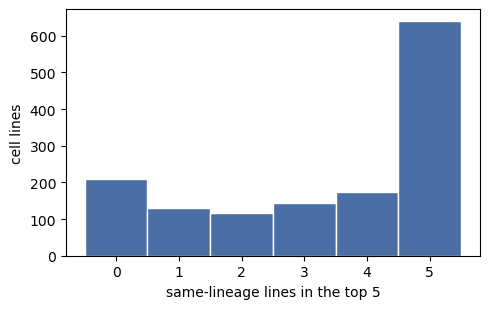

In [8]:
import duckdb, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

pdir = "../../data/parquet"

# same matrix construction as earlier in this notebook, so numbers stay comparable
expr = duckdb.sql(f"""
    SELECT ACH_ID, ensembl_id, median(log2_tpm_plus1) AS v
    FROM read_parquet('{pdir}/fact_expression_depmap.parquet')
    GROUP BY ACH_ID, ensembl_id
""").df()
wide = expr.pivot(index="ACH_ID", columns="ensembl_id", values="v").fillna(0)
top_genes = wide.var().nlargest(2000).index
X = wide[top_genes]

dim = pd.read_parquet(f"{pdir}/dim_cell_lines.parquet")
lin_map = dim.set_index("ach_id")["lineage"]
name_map = dim.set_index("ach_id")["cell_line_name"]

# keep only lines with a recorded lineage, then z-score as the service does
X = X[X.index.map(lin_map).notna()]
lin = X.index.map(lin_map).values
names = X.index.map(name_map).values
Z = StandardScaler().fit_transform(X)
sims = cosine_similarity(Z)
np.fill_diagonal(sims, -np.inf)          # never let a line match itself

# for every line, how many of its top 5 share its lineage
top5 = np.argsort(sims, axis=1)[:, -5:]
concord = np.array([(lin[row] == lin[i]).sum() for i, row in enumerate(top5)])

res = pd.DataFrame({"ach_id": X.index, "name": names, "lineage": lin, "concordance": concord})
print(f"cell lines tested: {len(res)}")
print(f"mean top-5 lineage concordance: {concord.mean():.2f} of 5")
print(f"  5 of 5: {(concord == 5).mean():.1%}")
print(f"  0 of 5: {(concord == 0).mean():.1%}")
print()
print(res.set_index("name").loc[["HCC827", "UBLC1"], ["lineage", "concordance"]].to_string())

# per-lineage separation, all lineages with at least five lines
rows = []
for L in pd.Series(lin).value_counts().index:
    idx = np.where(lin == L)[0]
    if len(idx) < 5:
        continue
    w = sims[np.ix_(idx, idx)][np.triu_indices(len(idx), k=1)]
    a = sims[np.ix_(idx, np.where(lin != L)[0])].ravel()
    rows.append({"lineage": L, "n": len(idx), "gap": w.mean() - a.mean()})
gaps = pd.DataFrame(rows).sort_values("gap")
print()
print(gaps.round(4).to_string(index=False))

# figure: how often the method returns same-lineage neighbours at all
plt.figure(figsize=(5, 3.2))
plt.hist(concord, bins=np.arange(-0.5, 6.5, 1), color="#4a6fa5", edgecolor="white")
plt.xlabel("same-lineage lines in the top 5")
plt.ylabel("cell lines")
plt.xticks(range(6))
plt.tight_layout()
plt.savefig("lineage_concordance.png", dpi=200)
plt.show()

In [9]:
from scipy.stats import spearmanr

sub_map = dim.set_index("ach_id")["Subtype"]
sub = X.index.map(sub_map).values

# diagonal was set to -inf for the top-5 search, so mask it out before averaging
D = sims.copy()
np.fill_diagonal(D, np.nan)

# test 1: inside lung, does each subtype separate from the other lung subtypes
lung = np.where(lin == "lung")[0]
print(f"lung as a single label, gap vs all other lineages: "
      f"{gaps.loc[gaps.lineage == 'lung', 'gap'].iloc[0]:.4f}\n")

rows = []
for s in pd.Series(sub[lung]).value_counts().index:
    idx = lung[sub[lung] == s]
    other = lung[sub[lung] != s]              # rest of lung, not rest of dataset
    if len(idx) < 5:
        continue
    w = np.nanmean(D[np.ix_(idx, idx)])
    a = np.nanmean(D[np.ix_(idx, other)])
    rows.append({"subtype": s[:45], "n": len(idx), "within": w, "vs other lung": a, "gap": w - a})
lung_tab = pd.DataFrame(rows).sort_values("gap", ascending=False)
print(lung_tab.round(4).to_string(index=False))

# test 2: across every lineage, does subtype diversity predict poor separation
div = []
for L in gaps["lineage"]:
    idx = np.where(lin == L)[0]
    # effective number of subtypes, so one dominant subtype plus a few strays counts as ~1
    p = pd.Series(sub[idx]).value_counts(normalize=True)
    div.append({"lineage": L, "n_subtypes": p.ne(0).sum(),
                "effective_subtypes": 1 / (p ** 2).sum()})
div = gaps.merge(pd.DataFrame(div), on="lineage")

r, pval = spearmanr(div["effective_subtypes"], div["gap"])
print(f"\nspearman, effective subtypes vs separation gap: rho = {r:.3f}, p = {pval:.4f}")
print(div.sort_values("gap").round(3).to_string(index=False))

lung as a single label, gap vs all other lineages: 0.0809

                                      subtype  n  within  vs other lung     gap
                Small Cell Lung Cancer (SCLC) 53  0.4003        -0.0322  0.4326
                                 Mesothelioma 20  0.3769        -0.0112  0.3881
Non-Small Cell Lung Cancer (NSCLC), Adenocarc 76  0.1863         0.0348  0.1514
Non-Small Cell Lung Cancer (NSCLC), Squamous  27  0.0999         0.0641  0.0358
Non-Small Cell Lung Cancer (NSCLC), Large Cel 17  0.0790         0.0553  0.0237
Non-Small Cell Lung Cancer (NSCLC), unspecifi 10  0.0635         0.0678 -0.0043

spearman, effective subtypes vs separation gap: rho = 0.050, p = 0.8100
                  lineage   n   gap  n_subtypes  effective_subtypes
                     lung 210 0.081           9               4.316
                   uterus  40 0.123           9               2.215
                    ovary  65 0.124          17               6.192
                  gastric  41 0.162 

                count   mean  median    min    max
group                                             
epithelial         16  0.231   0.207  0.081  0.440
non-epithelial     10  0.481   0.466  0.210  0.802

Mann-Whitney, non-epithelial > epithelial: U = 141, p = 0.0007


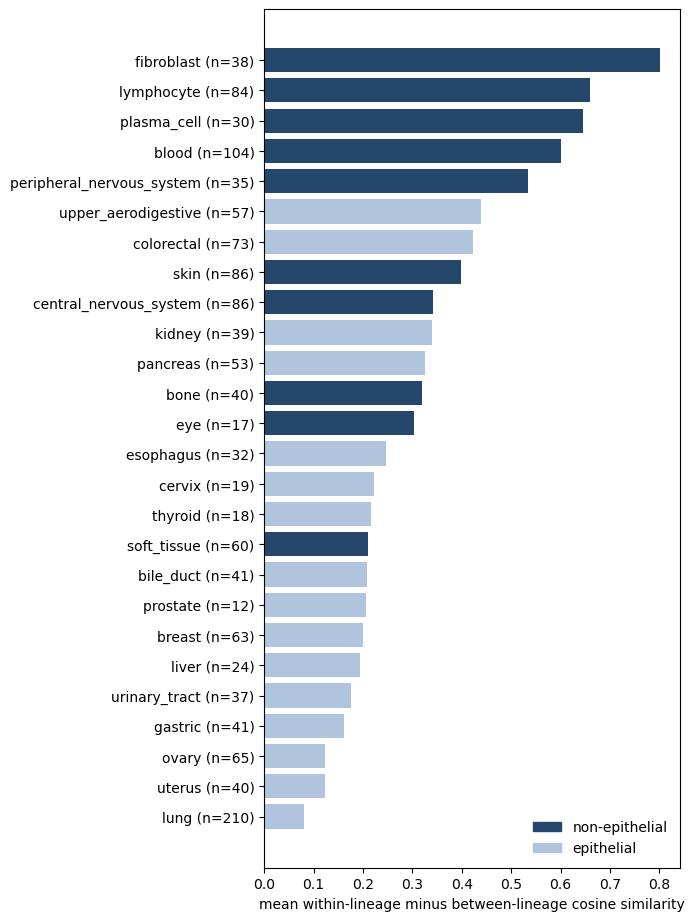

In [10]:
# coarse grouping: blood-derived and connective/neural tissue against solid epithelial organs
non_epithelial = {"blood", "lymphocyte", "plasma_cell", "fibroblast", "soft_tissue",
                  "bone", "central_nervous_system", "peripheral_nervous_system",
                  "skin", "eye"}

g = gaps.copy()
g["group"] = np.where(g["lineage"].isin(non_epithelial), "non-epithelial", "epithelial")

print(g.groupby("group")["gap"].agg(["count", "mean", "median", "min", "max"]).round(3).to_string())

from scipy.stats import mannwhitneyu
a = g.loc[g.group == "non-epithelial", "gap"]
b = g.loc[g.group == "epithelial", "gap"]
u, p = mannwhitneyu(a, b, alternative="greater")
print(f"\nMann-Whitney, non-epithelial > epithelial: U = {u:.0f}, p = {p:.4f}")

# figure: separation by lineage, coloured by the grouping tested above
colors = np.where(gaps["lineage"].isin(non_epithelial), "#24476b", "#b0c4de")

plt.figure(figsize=(7, 0.32 * len(gaps) + 1))
plt.barh(gaps["lineage"] + " (n=" + gaps["n"].astype(str) + ")", gaps["gap"], color=colors)
plt.xlabel("mean within-lineage minus between-lineage cosine similarity")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in ["#24476b", "#b0c4de"]]
plt.legend(handles, ["non-epithelial", "epithelial"], loc="lower right", frameon=False)
plt.tight_layout()
plt.savefig("lineage_separation.png", dpi=200)
plt.show()